In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_plot = pd.read_excel("diesel_output/pGWP_vs_GWP_ondiesel_per1000MJ.xlsx", sheet_name='plot', index_col = 0)
df_plot.head()

,"diesel, ecoinvent","diesel, premise","biodiesel, forest product (non-residual)","biodiesel, forest residues","biodiesel, used cooking oil","biodiesel, used cooking oil, with CCS","biodiesel, rapeseed oil"
premise_GWP100,21.964023,21.359482,-70.036611,-29.413906,-60.566544,-37.817759,-12.398170
"pGWP100, SSP1-19, MY2030",20.524144,19.928838,-70.123244,-29.765635,-60.901779,-38.166139,-20.001681
"pGWP100, SSP1-19, MY2040",20.995844,20.398592,-70.091143,-29.683013,-60.799281,-38.059862,-20.156658
"pGWP100, SSP1-19, MY2050",21.130222,20.532614,-70.084132,-29.665641,-60.771471,-38.031075,-20.698312
"pGWP100, SSP2-45, MY2030",20.243045,19.648794,-70.141250,-29.811622,-60.962128,-38.228687,-19.647134


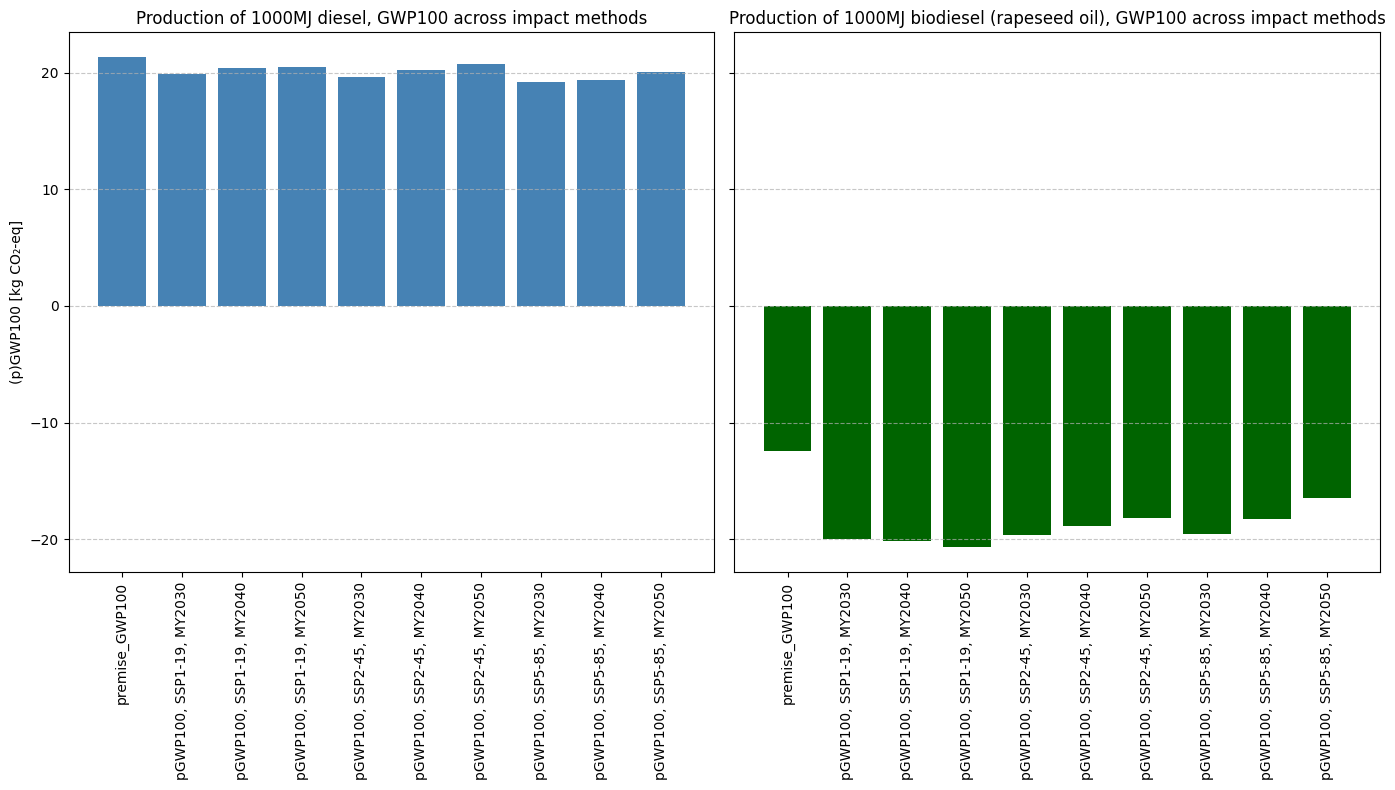

In [3]:
# Create two subplots comparing diesel and rapeseed oil across methods
fig, axs = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# 1 subplot: diesel, premise
axs[0].bar(df_plot.index, df_plot['diesel, premise'], color='steelblue')
axs[0].set_title("Production of 1000MJ diesel, GWP100 across impact methods")
axs[0].set_ylabel("(p)GWP100 [kg CO₂-eq]")
#axs[0].set_xlabel("Impact method")
axs[0].tick_params(axis='x', rotation=90)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)


# 2 subplot: biodiesel, rapeseed oil
axs[1].bar(df_plot.index, df_plot['biodiesel, rapeseed oil'], color='darkgreen')
axs[1].set_title("Production of 1000MJ biodiesel (rapeseed oil), GWP100 across impact methods")
#axs[1].set_xlabel("Impact method")
axs[1].tick_params(axis='x', rotation=90)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("pgWPvsGWP_diesel_vs_rapeseed_barplot.png")
plt.show()


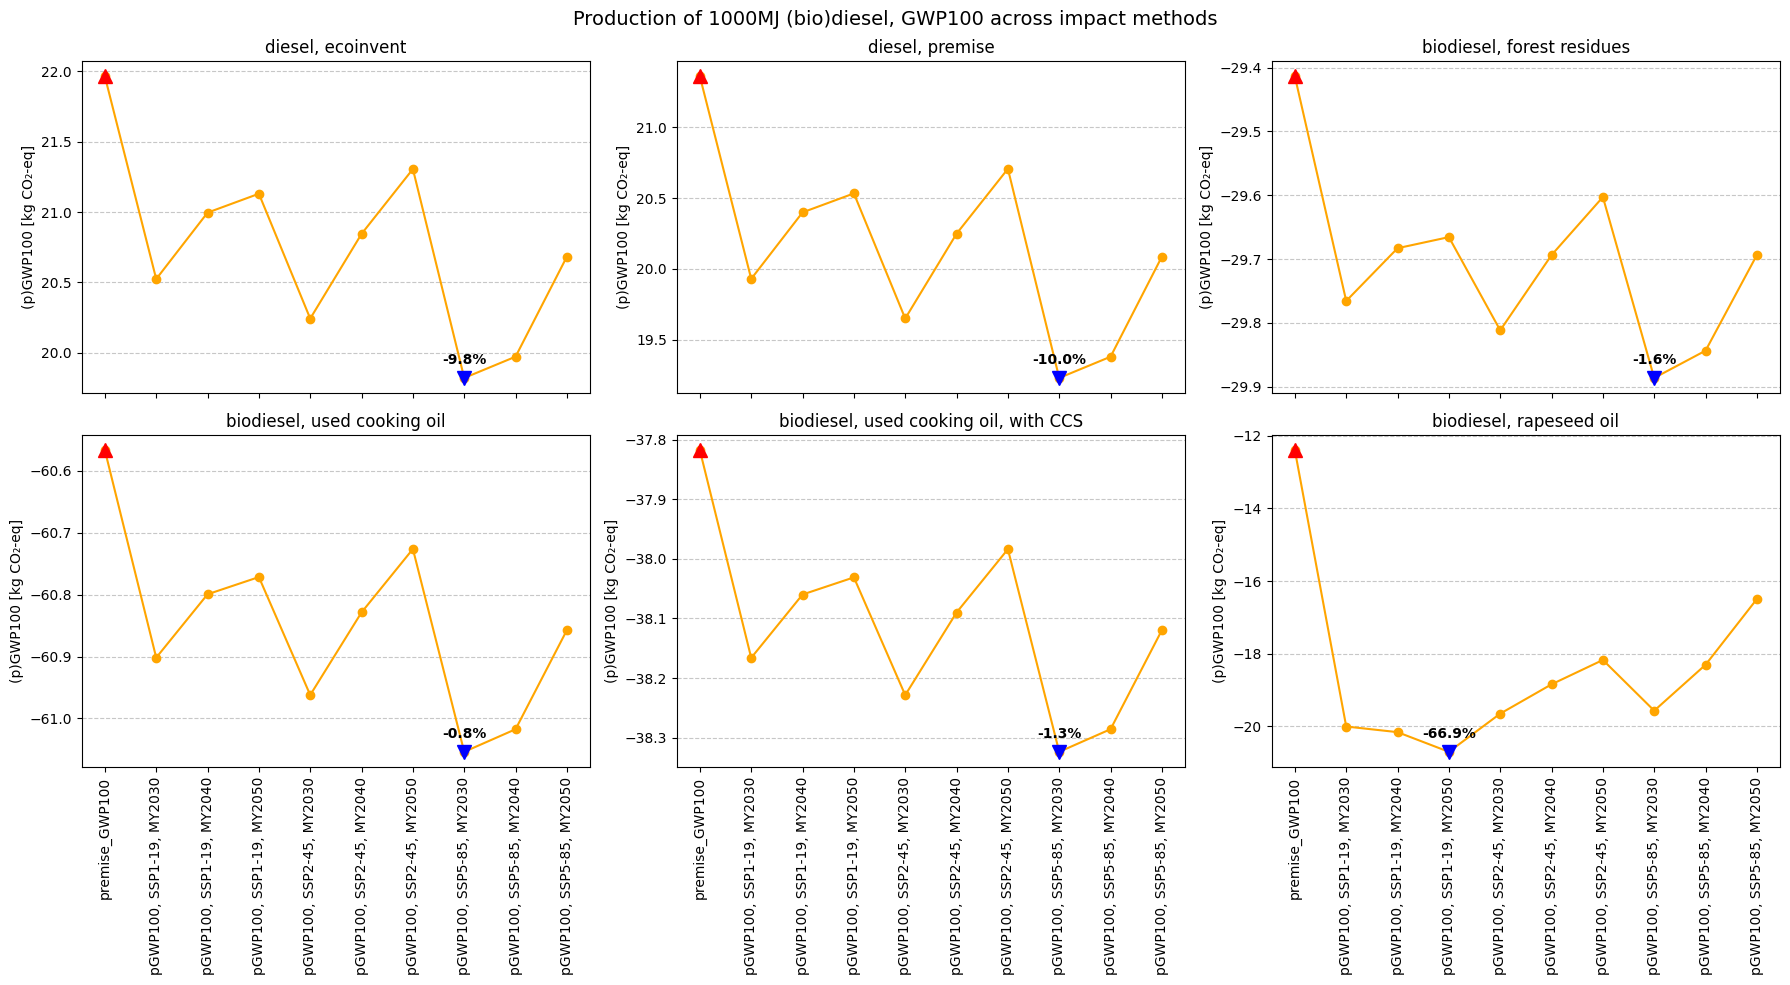

In [4]:
target_columns =  [
    'diesel, ecoinvent',
    'diesel, premise',
    'biodiesel, forest residues',
    'biodiesel, used cooking oil',
    'biodiesel, used cooking oil, with CCS',
    'biodiesel, rapeseed oil'
]

# now 6-panel line plots without shared y-axis, with annotations and highlights
fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axs = axs.flatten()

# each column with custom annotations: highest vs. lowest GWP 
for i, col in enumerate(target_columns):
    ax = axs[i]
    y = df_plot[col]
    
    # line and scatter points
    ax.plot(df_plot.index, y, marker='o', linestyle='-', color='orange', label=col)
    
    # min and max points
    min_idx = y.idxmin()
    max_idx = y.idxmax()
    ax.plot(min_idx, y[min_idx], marker='v', color='blue', label='Min', markersize=10)
    ax.plot(max_idx, y[max_idx], marker='^', color='red', label='Max', markersize=10)
    
    # largest % change between any two points
    percent_changes = ((y - y.iloc[0]) / abs(y.iloc[0])) * 100
    largest_change_idx = percent_changes.abs().idxmax()
    percent_change_value = percent_changes[largest_change_idx]
    ax.annotate(f"{percent_change_value:.1f}%", 
                xy=(largest_change_idx, y[largest_change_idx]), 
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, color='black', fontweight='bold')

    ax.set_title(col, fontsize = 12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_ylabel("(p)GWP100 [kg CO₂-eq]")

# if bottom row x-axis
#for ax in axs[3:]:
#    ax.set_xlabel("Impact Method")

plt.suptitle("Production of 1000MJ (bio)diesel, GWP100 across impact methods", fontsize = 14)
plt.tight_layout()
plt.savefig("pgWPvsGWP_6diesel_lineplot.png")
plt.show()


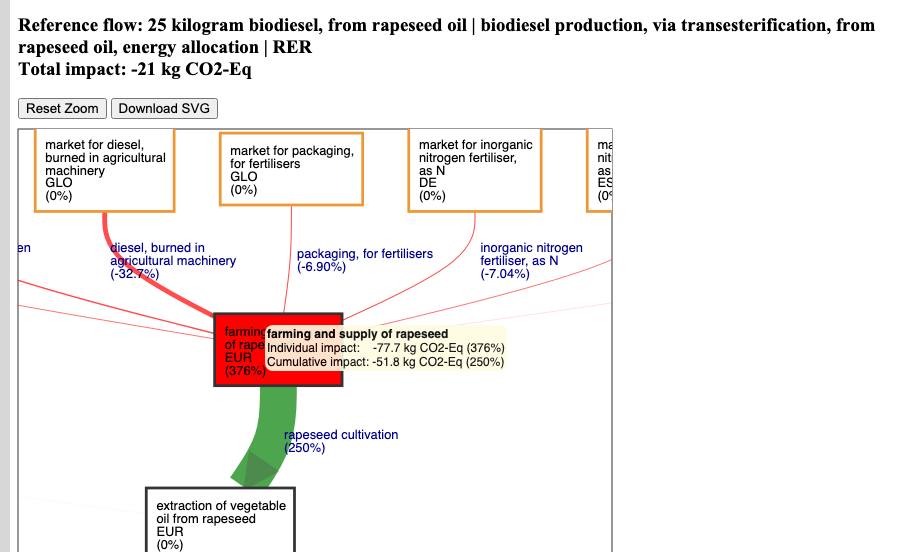